shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.


In [1]:
import torch
from tqdm import tqdm
import numpy as np
from dataloader import create_dataloaders
from models.registry import REGISTRY

In [2]:
# device = "cuda"
!ls
!pwd
device = "cpu"
data_config = "config/baseline.yml"
model_type = "towards-model-2"

model_cfg = REGISTRY[model_type]
input_type = model_cfg["input_type"]
task_type = model_cfg["task_type"]

train_loader, val_loader, test_loader = create_dataloaders(
    data_config,
    batch_size=128,
    shuffle=False,
    val_size=0.2,
    input_type=input_type,
    target_type=task_type,
    label_format="index",
    apply_scaling=True,
)


README.md    config	    dataset.py	    models	 train.ipynb
__pycache__  dataloader.py  evaluate.ipynb  plotting.py  utils.py
/data/kshitij/SmartPixelsHackathon
Built transform with input_type=y-profile, scaling=enabled
Built target transform with target_type=classification, scaling=enabled


100%|██████████| 100/100 [00:02<00:00, 42.72it/s]


(12800, 14) (12800,)


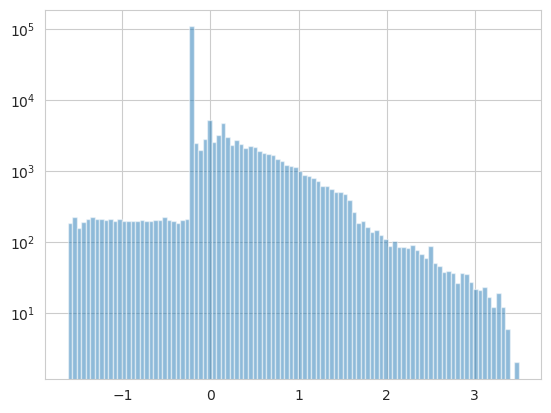

<Figure size 640x480 with 0 Axes>

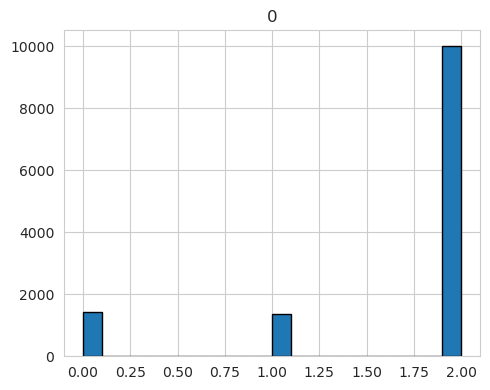

<Figure size 640x480 with 0 Axes>

In [4]:
# reload potting
from importlib import reload
import plotting
reload(plotting)

plotting.plot_data_distributions(train_loader)

In [18]:
model = model_cfg["class"]()

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {n_params}")


TowardsModel2(
  (fc1): Linear(in_features=14, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (softmax): Softmax(dim=1)
)
Number of trainable parameters: 2307


In [19]:
labels = train_loader.dataset.get_all_class_labels()
counts = np.bincount(labels)
weights = 1.0 / counts
weights = weights / weights.sum()
print("Class counts:", counts)
print("Class weights:", weights)

Class counts: [11067 11303 77630]
Class weights: [0.47132429 0.46148331 0.0671924 ]


In [27]:

if task_type == "classification":
    # criterion = torch.nn.CrossEntropyLoss()
    criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float,device=device))  # Adjust weights for class imbalance
elif task_type == "regression":
    criterion = torch.nn.MSELoss()
else:
    raise ValueError(f"Unknown task: {task_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model.to(device)

# this is optional: make the first iteration slow, but faster afterwards
# model.compile()


TowardsModel2(
  (fc1): Linear(in_features=14, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (softmax): Softmax(dim=1)
)

In [ ]:
N_EPOCHS = 10
EVAL_FREQ = 200
OUT_PATH = "output"


global_step, best_val_loss = 0, float('inf')
for epoch in range(N_EPOCHS):
    running_loss, running_n = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Training epoch {epoch+1}/{N_EPOCHS}", unit="batch")
    for step_in_epoch, (inputs, labels) in enumerate(pbar):
        step = global_step 
        global_step += 1

        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss
        running_n += 1

        # if step % 10 == 0:
        pbar.set_postfix({
            "running loss": f"{running_loss.item() / running_n:.3f}",
            "loss": f"{loss.item():.3f}"
        })

        if EVAL_FREQ > 0 and step % EVAL_FREQ == 0:
            val_loss, val_acc, val_n = 0.0, 0.0, 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss
                    if task_type == "classification":
                        preds = outputs.argmax(dim=1)
                        val_acc += (preds == labels).float().mean().item()
                    val_n += 1

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model, f"{OUT_PATH}/best_model.pth")


Training epoch 7/10:  13%|█▎        | 105/782 [00:05<00:21, 32.10batch/s, running loss=0.397, loss=0.414]

In [ ]:
# evaluate the model performance on the test set
